#### Summary
In this file we are going to perform EDA of zomato-data for different orders and sales

In [2]:
# importint necessary modules

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme()

In [4]:
%matplotlib inline

In [5]:
# Importing our dataframe
df = pd.read_csv('Zomato-data-.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
# Checking about its data-types and other informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [7]:
# Checking about null values
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [8]:
# Checking for duplicated values
df.duplicated().sum()

np.int64(0)

In [9]:
# Changing name of approx_cost(for two people) to cost
df.rename({'approx_cost(for two people)':'cost','listed_in(type)':'type','rate':'ratings'}, axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          148 non-null    object
 1   online_order  148 non-null    object
 2   book_table    148 non-null    object
 3   ratings       148 non-null    object
 4   votes         148 non-null    int64 
 5   cost          148 non-null    int64 
 6   type          148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [11]:
# Now analysing store prices
cost = df['cost']

In [12]:
cost.describe()

count    148.000000
mean     418.243243
std      223.085098
min      100.000000
25%      200.000000
50%      400.000000
75%      600.000000
max      950.000000
Name: cost, dtype: float64

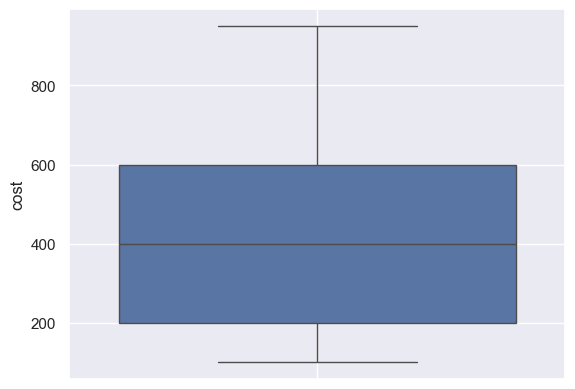

In [34]:
sns.boxplot(cost).grid(1)

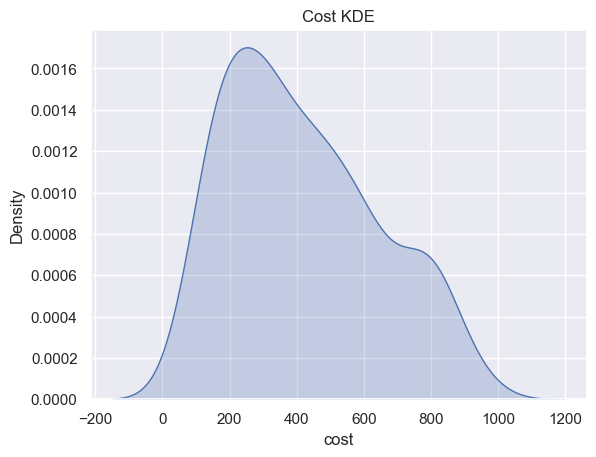

In [14]:
sns.kdeplot(cost, fill=True).grid(1)
plt.title('Cost KDE')
plt.show()

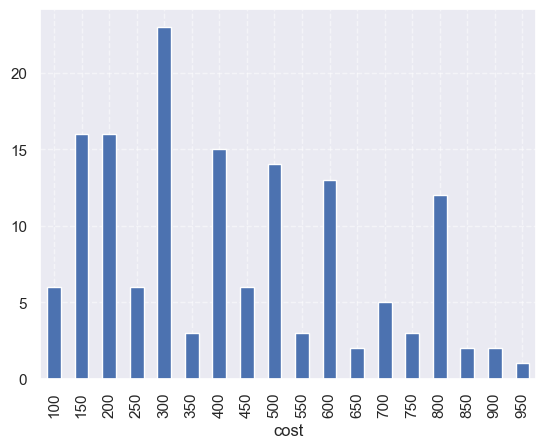

In [15]:
cost.value_counts().sort_index().plot(kind='bar').grid(1, linestyle='--', alpha=0.5)

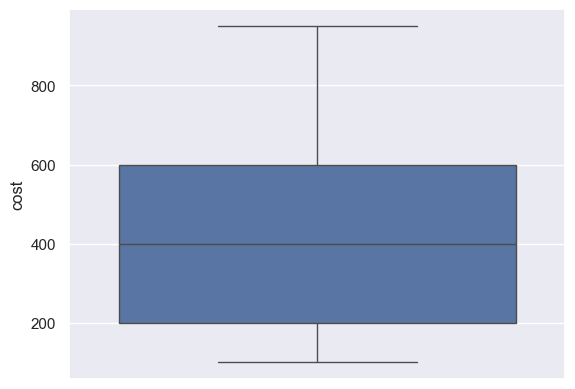

In [16]:
sns.boxplot(cost)
plt.show()

In [17]:
# Creating favoured percentage column
df['favoured_%']=(((df['ratings']
                   .str
                   .split("/", expand=True)
                   .astype('float')
                   .pipe(lambda x:x[0]/x[1])
                   *df['votes'])
                   /df['votes'])
                   *100).round()

In [18]:
df.head()

,name,online_order,book_table,ratings,votes,cost,type,favoured_%
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet,82.0
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet,82.0
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet,76.0
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet,74.0
4,Grand Village,No,No,3.8/5,166,600,Buffet,76.0


In [19]:
favoured_stores = df.nlargest(5,'favoured_%')[['name','ratings','votes','type','cost','favoured_%']]
favoured_stores.head()

,name,ratings,votes,type,cost,favoured_%
7,Onesta,4.6/5,2556,Cafes,600,92.0
44,Onesta,4.6/5,2556,other,600,92.0
38,Empire Restaurant,4.4/5,4884,other,750,88.0
86,Meghana Foods,4.4/5,4401,Dining,600,88.0
52,Corner House Ice Cream,4.3/5,345,Dining,400,86.0


As you can see **Onesta** is most favoured store with favoured percentage of **92 %** and ratings of **4.6** out of **5**. <br>
However **Empire Restaurant** and **Meghana Foods** are also very good as they have higher votes indicating that they have **high customer flow**.

In [20]:
least_favoured = df.nsmallest(5,'favoured_%')[['name','ratings','votes','type','cost','favoured_%']]
display(least_favoured)

,name,ratings,votes,type,cost,favoured_%
94,Nandhini Deluxe,2.6/5,283,Dining,600,52.0
31,Foodiction,2.8/5,506,other,500,56.0
36,Fast And Fresh,2.8/5,91,Dining,400,56.0
73,LSD Cafe,2.9/5,84,other,700,58.0
124,Kwality Wall's Swirl's Happiness Station,2.9/5,25,Dining,200,58.0


Here least favoured stores are **Nandhini Deluxe** with **favourability percentage of 52** and ratings **2.6 out of 5** <br>
But **Foodiction** has **higher votes with low ratings** indicating that it is also **very poor**

In [21]:
# Now most visited hotel is with higher votes
df.loc[df['votes']==df['votes'].max()]

,name,online_order,book_table,ratings,votes,cost,type,favoured_%
38,Empire Restaurant,Yes,No,4.4/5,4884,750,other,88.0


In [22]:
# Now converting online_order and book_table to number for our machine
df['online_order'].map({'Yes':1,'No':0})

0      1
1      1
2      1
3      0
4      0
      ..
143    0
144    0
145    1
146    0
147    1
Name: online_order, Length: 148, dtype: int64

In [23]:
df['book_table'] = df['book_table'].map({'Yes':1,"No":0})

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
le = LabelEncoder()

In [26]:
df['type']=le.fit_transform(df['type'])

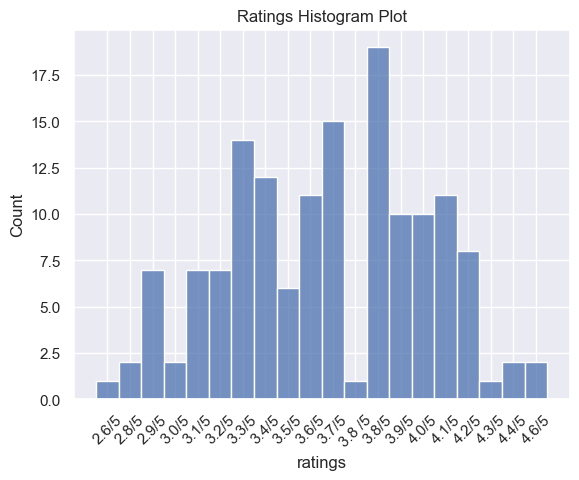

In [27]:
sns.histplot(df['ratings'].sort_values())
plt.title('Ratings Histogram Plot')
plt.xticks(rotation=45)
plt.show()

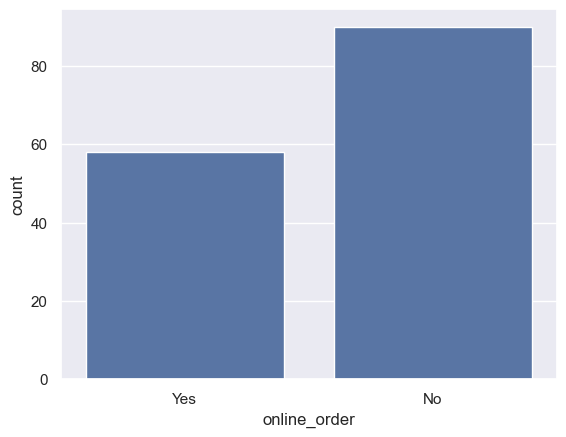

In [28]:
sns.countplot(x='online_order',data=df)
plt.show()

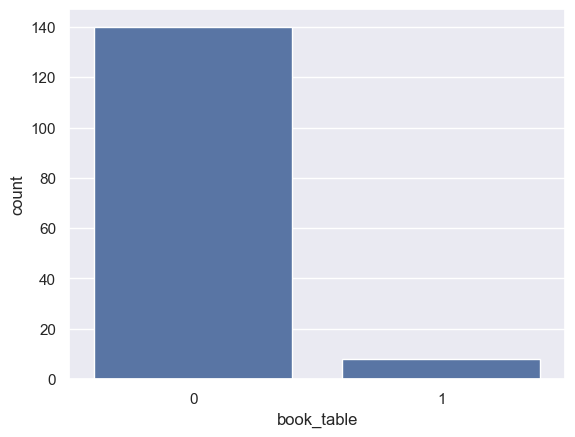

In [29]:
sns.countplot(x='book_table',data=df)
plt.show()

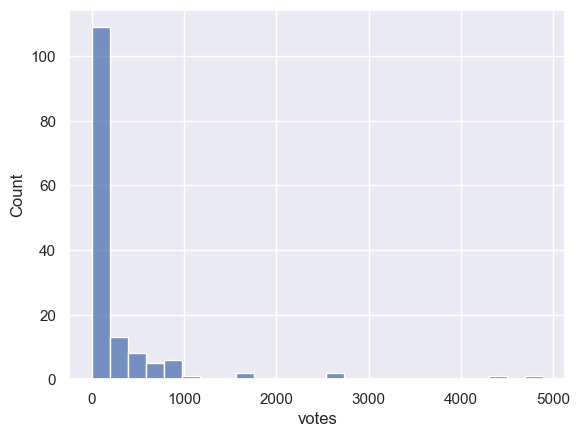

In [30]:
sns.histplot(df['votes'])
plt.show()

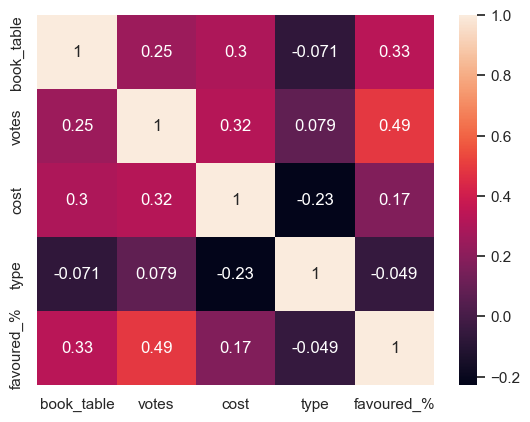

In [31]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

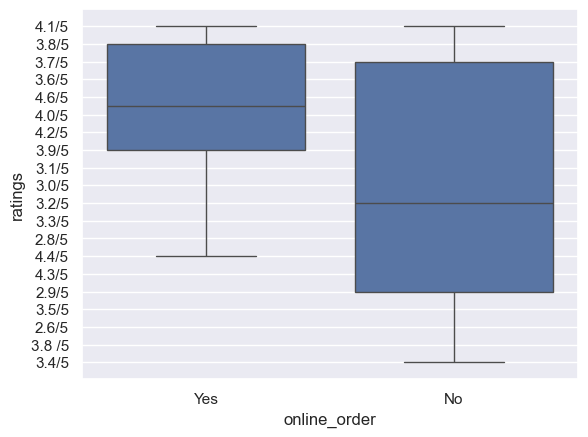

In [32]:
sns.boxplot(x='online_order',
            y='ratings',
            data=df)
plt.show()

<Axes: xlabel='cost', ylabel='ratings'>

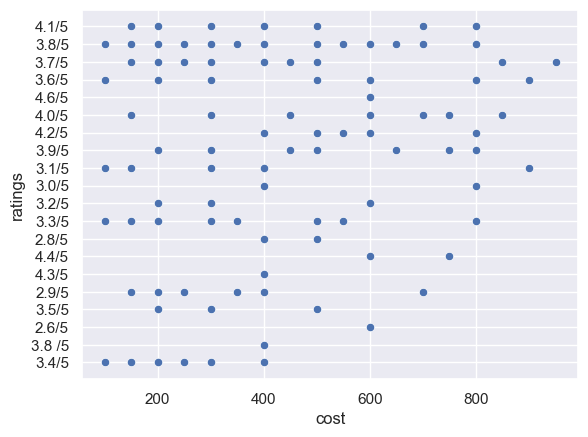

In [33]:
sns.scatterplot(x='cost',
                y='ratings',
                data=df)